In [19]:
#Ground Track Visualization using skyfield

In [20]:
#Step 1: Initialize Libraries
import ephem
import matplotlib.pyplot as plt
from datetime import datetime
from skyfield.api import utc
from skyfield import api

In [21]:
#Step 2: Define TLE Data
station_data = api.load.tle('https://celestrak.org/NORAD/elements/gp.php?GROUP=stations&FORMAT=tle')
iss = station_data['ISS (ZARYA)']
print(iss)

ISS (ZARYA) catalog #25544 epoch 2026-08-01 02:05:42 UTC


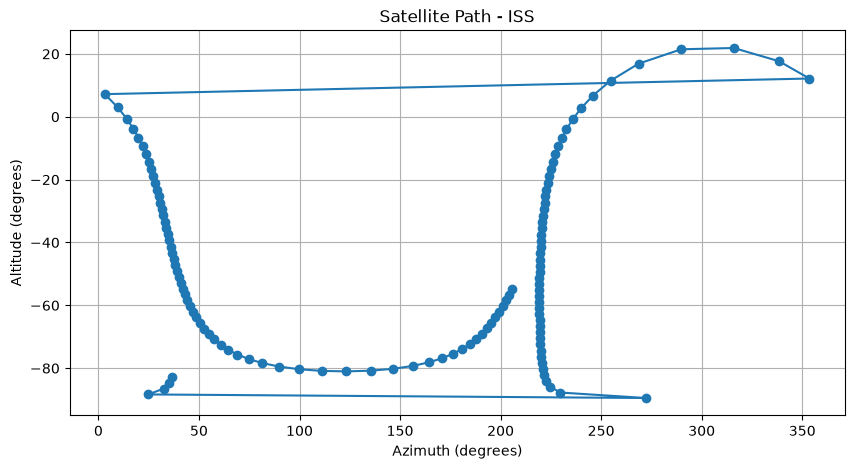

In [22]:
#Step 3: Define Time Range
## Change to your specified time range. Current: 2 hours
minutes = range(60 * 2)
time_range = time_scale.utc(2024, 3, 21, 2, minutes)
altitudes = []
azimuths = []

for t in time_range:
    # Calculate satellite position at each time step
    port_hedland = api.Topos(latitude='20.3123 S', longitude='118.64498 E')
    orbit = (iss - port_hedland).at(t)
    altitude, azimuth, distance = orbit.altaz()
    
    # Append the altitude and azimuth values to the lists
    altitudes.append(altitude.degrees)
    azimuths.append(azimuth.degrees)
plt.figure(figsize=(10, 5))
plt.plot(azimuths, altitudes, marker='o', linestyle='-')
plt.title("Satellite Path - ISS")
plt.xlabel("Azimuth (degrees)")
plt.ylabel("Altitude (degrees)")
plt.grid(True)
plt.show()

In [23]:
#Polar Plot of Passes using skyfield

In [24]:
#Step 1: Initialize Libraries
from skyfield import api
from pytz import timezone
import numpy as np

## Change to your time zone
time_zone = timezone('US/Pacific')

In [25]:
#Step 2: Access TLE Files
station_data = api.load.tle('https://celestrak.org/NORAD/elements/gp.php?GROUP=stations&FORMAT=tle')
iss = station_data['ISS (ZARYA)']
print(iss)

ISS (ZARYA) catalog #25544 epoch 2026-08-01 02:05:42 UTC


In [26]:
#Step 3: Declare Time Range of Pass
# Current time range (in minutes) = 2 days. Change to your values
time_scale = api.load.timescale()
minutes = range(60 * 24 * 2)
## Change to your specified time range
time_range = time_scale.utc(2024, 3, 21, 2, minutes)

In [27]:
#Step 4: Obtaining Relative Orbital Details
# Change to your specified geocoordinates. Current geocoordinates = Port Hedland in Australia 
port_hedland = api.Topos(latitude='20.3123 S', longitude='118.64498 E')
orbit = (iss - port_hedland).at(time_range)
altitude, azimuth, distance = orbit.altaz()
print(f"Altitudes: {altitude}")
print(f"Azimuth: {azimuth}")
print(f"Distance: {distance}")

Altitudes: 2880 values from -82deg 39' 11.3" to -36deg 01' 54.9"
Azimuth: 2880 values from 36deg 24' 56.9" to 37deg 06' 36.8"
Distance: [8.75318840e-05 8.78476164e-05 8.80721370e-05 ... 5.02330059e-05
 5.25358726e-05 5.47840685e-05] au


In [28]:
#Step 5+6: Find rise/set pass boundaries (robust to partial passes at the edges)
is_up = altitude.degrees > 0
diff = np.diff(is_up.astype(int))
rises = np.where(diff == 1)[0] + 1
sets = np.where(diff == -1)[0] + 1

if is_up[0]:
    rises = np.insert(rises, 0, 0)
if is_up[-1]:
    sets = np.append(sets, len(is_up) - 1)

passes = list(zip(rises, sets))
print(passes)

[(np.int64(48), np.int64(58)), (np.int64(760), np.int64(767)), (np.int64(855), np.int64(866)), (np.int64(955), np.int64(962)), (np.int64(1353), np.int64(1363)), (np.int64(1450), np.int64(1461)), (np.int64(2164), np.int64(2169)), (np.int64(2258), np.int64(2269)), (np.int64(2357), np.int64(2365)), (np.int64(2757), np.int64(2765)), (np.int64(2853), np.int64(2864))]


In [29]:
#Step 7: Getting the Rise and Set Time
# Set this value to any index from 0 to len(boundaries)! This represents the pass we want to observe from our list of collected passes
pass_to_observe = 0
rise, set = passes[pass_to_observe]
print(f'ISS Rises at {time_range[rise].astimezone(time_zone)}')
print(f'ISS Sets at {time_range[set].astimezone(time_zone)}')

ISS Rises at 2024-03-20 19:48:00-07:00
ISS Sets at 2024-03-20 19:58:00-07:00


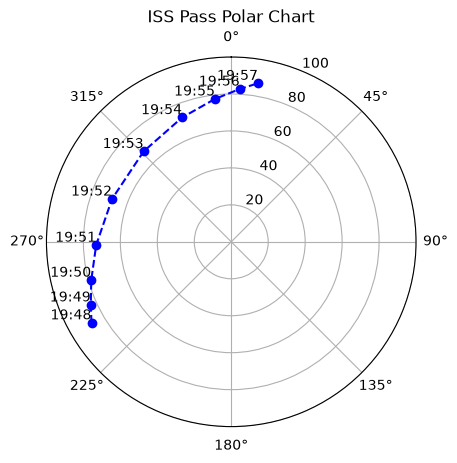

In [30]:
#Step 8: Visualizing the Polar Plot
ax = plt.subplot(111, projection='polar')
plt.title("ISS Pass Polar Chart")
ax.set_rlim([0, 100])
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

θ = azimuth.radians
r = 90 - altitude.degrees
ax.plot(θ[rise:set], r[rise:set], 'bo--')

for k in range(rise, set):
    text = time_range[k].astimezone(time_zone).strftime('%H:%M')
    ax.text(θ[k], r[k], text, ha='right', va='bottom')